In [2]:
import pandas as pd
import numpy as np
from sklearn.metrics import confusion_matrix
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

data = pd.read_csv('RFE_SolCbio3_descs_fps.csv') #import filtered descriptors
data.drop(columns=['smiles'], inplace=True) #remove unwanted columns

In [3]:
from sklearn.model_selection import StratifiedShuffleSplit
from sklearn.model_selection import train_test_split

# Create a new column 'output' by mapping 'dev' column
data['output'] = data['dev'].map({'NO': 0, 'YES': 1})

# Delete the original 'dev' column
data.drop(columns=['dev'], inplace=True)


X = data.drop('output', axis=1)
y = data['output']


sss = StratifiedShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
for train_index, test_index in sss.split(X, y):
  X_train, X_test = X.iloc[train_index], X.iloc[test_index]
  y_train, y_test = y.iloc[train_index], y.iloc[test_index]

  X_train_val, X_val, y_train_val, y_val = train_test_split(X_train, y_train, test_size=0.2, random_state=42, stratify=y_train)

  # Now you have stratified samples in X_train, X_test, y_train, and y_test

print(f'Training set (80%): {X_train.shape}')
print(f'Validation set (20% of TS): {X_val.shape}')
print(f'Test set (20%): {X_test.shape}')
print(f'Accurate predictions of GSE in test set: {100*round(y_test.value_counts()[0]/len(y_test),3)} %')
print(f'Accurate predictions of GSE in validation set: {100*round(y_val.value_counts()[0]/len(y_val),3)} %')
print(f'Accurate predictions of GSE in training set: {100*round(y_train.value_counts()[0]/len(y_train),3)} %')

Training set (80%): (2192, 75)
Validation set (20% of TS): (439, 75)
Test set (20%): (548, 75)
Accurate predictions of GSE in test set: 65.3 %
Accurate predictions of GSE in validation set: 65.4 %
Accurate predictions of GSE in training set: 65.4 %


In [3]:
import joblib

# Load the model and threshold dictionary
loaded_data = joblib.load('RF_optimized_model_with_threshold.pkl')

loaded_RF_model = loaded_data['model']
loaded_threshold = loaded_data['threshold']

print(f"Loaded RF model: {loaded_RF_model}")
print(f"Loaded threshold: {loaded_threshold:.3f}")

Loaded RF model: RandomForestClassifier(criterion='entropy', max_depth=30, min_samples_leaf=2,
                       min_samples_split=5, random_state=42)
Loaded threshold: 0.353


In [4]:
!pip uninstall numpy -y
!pip install "numpy<2.0"
import numpy as np
print(np.__version__)

Found existing installation: numpy 1.26.4
Uninstalling numpy-1.26.4:
  Successfully uninstalled numpy-1.26.4
  Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl.metadata (61 kB)
Using cached numpy-1.26.4-cp312-cp312-manylinux_2_17_x86_64.manylinux2014_x86_64.whl (18.0 MB)
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
aqme 1.7.2 requires rdkit==2024.3.3, but you have rdkit 2023.9.6 which is incompatible.
1.26.4


import shap

# Define a custom prediction function that applies the decision threshold
def predict_with_threshold(model, threshold, X):
    probabilities = model.predict_proba(X)[:, 1] # Get probabilities for the positive class
    return (probabilities >= threshold).astype(int) # Apply the threshold for binary classification


explainer = shap.KernelExplainer(lambda X: predict_with_threshold(loaded_RF_model, loaded_threshold, X), shap.sample(X_train_val,100))

# Calculate SHAP values
shap_values = explainer(X_test)

print("SHAP values calculated using the custom threshold.")

import shap
from sklearn.model_selection import KFold

features = list(X_train_val.columns)

def predict_with_threshold(model, threshold, X):
    if not isinstance(X, pd.DataFrame):
        X = pd.DataFrame(X, columns=features)
    probabilities = model.predict_proba(X)[:, 1]
    return (probabilities >= threshold).astype(int)

def safe_predict(X_input):
    return predict_with_threshold(loaded_RF_model, loaded_threshold, X_input)

# 10-fold CV on X_train_val
kf = KFold(n_splits=10, shuffle=False)

all_shap_values = []   # will hold SHAP arrays for each validation sample
all_indices = []       # optional: keep track of original row indices

for train_idx, val_idx in kf.split(X_train_val, y_train_val):
    # Background data: training fold
    X_background = X_train_val.iloc[train_idx]
    exp_fold = shap.TreeExplainer(safe_predict, X_background)
    
    # SHAP values for validation fold (class 1)
    shap_val = exp_fold.shap_values(X_train_val.iloc[val_idx])[1]  # shape = (n_val, n_features)
    all_shap_values.append(shap_val)
    all_indices.extend(val_idx)

# Combine all SHAP values (order matches X_train_val)
# Since KFold with shuffle=False gives non‑overlapping validation sets,
# you can concatenate in the order of folds.
shap_matrix = np.vstack(all_shap_values)   # shape = (n_samples, n_features)

# Expected value (base probability) – same for all folds
expected_value = exp_fold.expected_value[1]   # for class 1# for class 1

import shap
from sklearn.model_selection import KFold

features = list(X_train_val.columns)
explainer = shap.TreeExplainer(loaded_RF_model)

# 10-fold CV on X_train_val
kf = KFold(n_splits=10, shuffle=False)

# For storing SHAP values and row indices
all_shap_values = []
all_indices = []

for train_idx, val_idx in kf.split(X_train_val, y_train_val):
    # SHAP values for the validation fold (class 1)
    shap_val = explainer.shap_values(X_train_val.iloc[val_idx])[1]   # (n_val, n_features)
    all_shap_values.append(shap_val)
    all_indices.extend(val_idx)   # remember original row positions

# Combine into one matrix, ordered by the validation indices
shap_matrix = np.vstack(all_shap_values)          # (n_samples, n_features)

# Expected value for class 1 (global base probability)
expected_value = explainer.expected_value[1]

In [5]:
import shap
from sklearn.model_selection import KFold

features = list(X.columns)

kf = KFold(n_splits=10, shuffle=False)
n_samples = len(X)
shap_matrix = np.zeros((n_samples, len(features)))  # pre‑allocate

for train_idx, val_idx in kf.split(X, y):
    explainer = shap.TreeExplainer(loaded_RF_model)   # or reuse outside loop – but careful with background
    shap_val = explainer.shap_values(X.iloc[val_idx])[:, :, 1]
    shap_matrix[val_idx, :] = shap_val   # assign to original positions




In [6]:
expected_value = explainer.expected_value[1] 

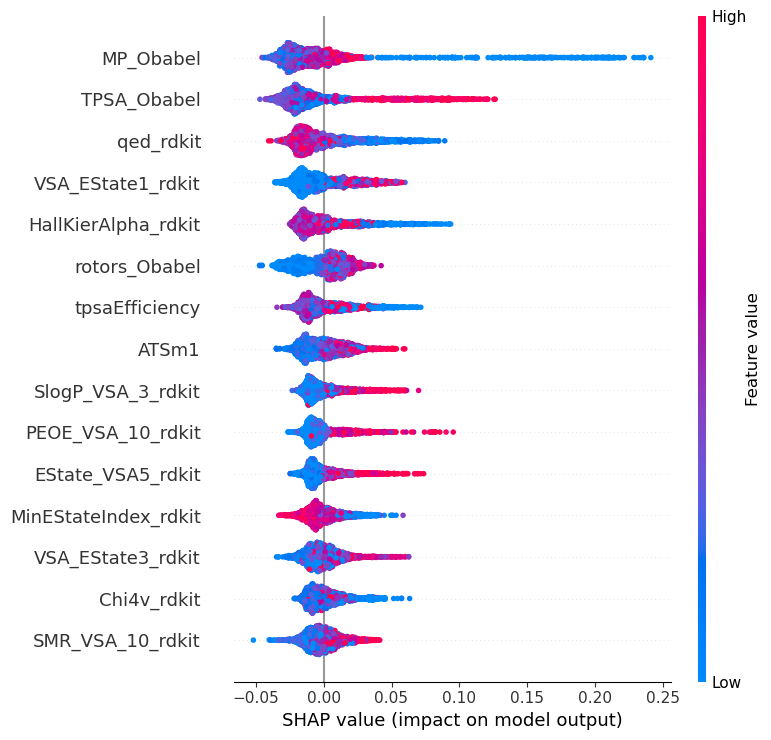

In [7]:
# Requires the original feature matrix (X_train_val) and the SHAP matrix
shap.summary_plot(shap_matrix, X, feature_names=features, max_display = 15, show=False)
plt.savefig('shap_summary_plot.png', format='png', dpi=500, bbox_inches='tight')
plt.savefig('shap_summary_plot.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.show()

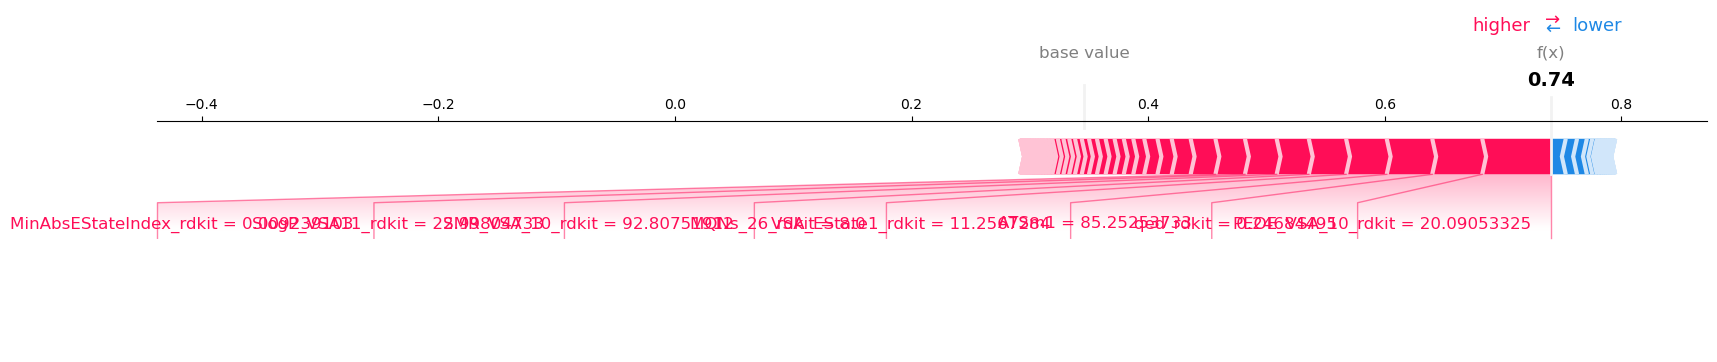

<Figure size 640x480 with 0 Axes>

In [8]:
shap.initjs()   # for Jupyter notebook
shap.force_plot(expected_value, shap_matrix[0,:], X.iloc[0,:],
                feature_names=features, matplotlib=True)
fig = plt.gcf()

plt.savefig('shap_force_plot_noGSE.pdf', format='pdf', dpi=500, bbox_inches='tight')
plt.savefig('shap_force_plot_noGSE.png', format='png', dpi=500, bbox_inches='tight')
plt.show()

In [9]:
# Create the waterfall plot without showing it
shap.plots.waterfall(
    shap.Explanation(
        values=shap_matrix[2739, :],
        base_values=expected_value,
        data=X.iloc[2739, :].values,
        feature_names=features
    ),
    show=False                # <-- key: don't display automatically
)

# Get the current figure and save it
fig = plt.gcf()
fig.savefig('shap_waterfall_plot_noGSE.png', dpi=300, bbox_inches='tight')
fig.savefig('shap_waterfall_plot_noGSE.pdf', dpi=500, bbox_inches='tight')

In [10]:
shap.plots.waterfall(shap.Explanation(values=shap_matrix[3,:],
                                      base_values=expected_value,
                                      data=X.iloc[3,:].values,
                                      feature_names=features),
                    show=False)
fig2 = plt.gcf()
fig2.savefig('shap_waterfall_plot_GSE.png', format='png', dpi=300, bbox_inches='tight')
fig2.savefig('shap_waterfall_plot_GSE.pdf', format='pdf', dpi=500, bbox_inches='tight')
fig2.show()

In [11]:
y

0       1
1       1
2       1
3       0
4       1
       ..
2735    1
2736    0
2737    1
2738    1
2739    1
Name: output, Length: 2740, dtype: int64

In [6]:
X['TPSA_Obabel'][3]

18.46